In [1]:
import numpy as np
import xarray as xr
import pandas as pd 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [2]:
era5 = xr.open_dataset(r"D:\\Documents\\thesis\\processed_data\\era5-land-all-variables\\era5land_ebro_daily_mean3.nc")
df = era5.to_dataframe()
df = df.drop(columns=['number', 'spatial_ref'])
df['day_of_year'] = df.index.dayofyear
df['tp_30d_sum'] = df['tp'].rolling(window=30, center=False).sum()
top_features = ['swvl1', 'ssrd', 'pev', 'day_of_year', 'swvl2', 'skt', 'tp_30d_sum']
df = df[top_features]
df = df.dropna()
df = df.resample('D').mean()
# Separate inputs and output
#column_names = df.columns.tolist()
column_names = ['ssrd', 'pev', 'day_of_year', 'swvl2', 'skt', 'tp_30d_sum']
column_names = ['ssrd', 'pev', 'day_of_year', 'swvl2']
X = df[column_names].values
y = df[['swvl1']].values

# normalize the data
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

LSTM

In [ ]:
def create_sequences(X, y, look_back=60, forecast_horizon=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - look_back - forecast_horizon + 1):
        X_seq.append(X[i : i + look_back])
        y_seq.append(y[i + look_back + forecast_horizon - 1])  # value at t+30
    return np.array(X_seq), np.array(y_seq)

look_back = 60
forecast_horizon = 30
X_seq, y_seq = create_sequences(X_scaled, y_scaled, look_back, forecast_horizon)

print("X shape:", X_seq.shape)
print("y shape:", y_seq.shape) 

split = int(0.8 * len(X_seq))

# Split into train and test sets
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

class SoilMoistureLSTM(nn.Module):
    def __init__(self, input_size=6, hidden_size=32, num_layers=2):  # 64 → 32
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)
    
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

# Create dataset and dataloader
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)  # shuffle=False for time series

model = SoilMoistureLSTM(input_size=len(column_names), hidden_size=32)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 50
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {epoch_loss / len(train_loader):.4f}")

model.eval()
with torch.no_grad():
    preds = model(X_test_t).numpy()

# Convert back to original scale
preds_inv = scaler_y.inverse_transform(preds)
y_test_inv = scaler_y.inverse_transform(y_test)

rmse = np.sqrt(mean_squared_error(y_test_inv, preds_inv))
r2 = r2_score(y_test_inv, preds_inv)
mae = mean_absolute_error(y_test_inv, preds_inv)

print("RMSE:", rmse)
print("R2:", r2)
print("MAE:", mae)

X shape: (13000, 60, 4)
y shape: (13000, 1)
Epoch 0, Loss: 0.6148
Epoch 10, Loss: 0.5287
Epoch 20, Loss: 0.5162
Epoch 30, Loss: 0.5056
Epoch 40, Loss: 0.4990
RMSE: 0.05725415877748308
R2: 0.499575138092041
MAE: 0.045020777732133865


True values vs predicted

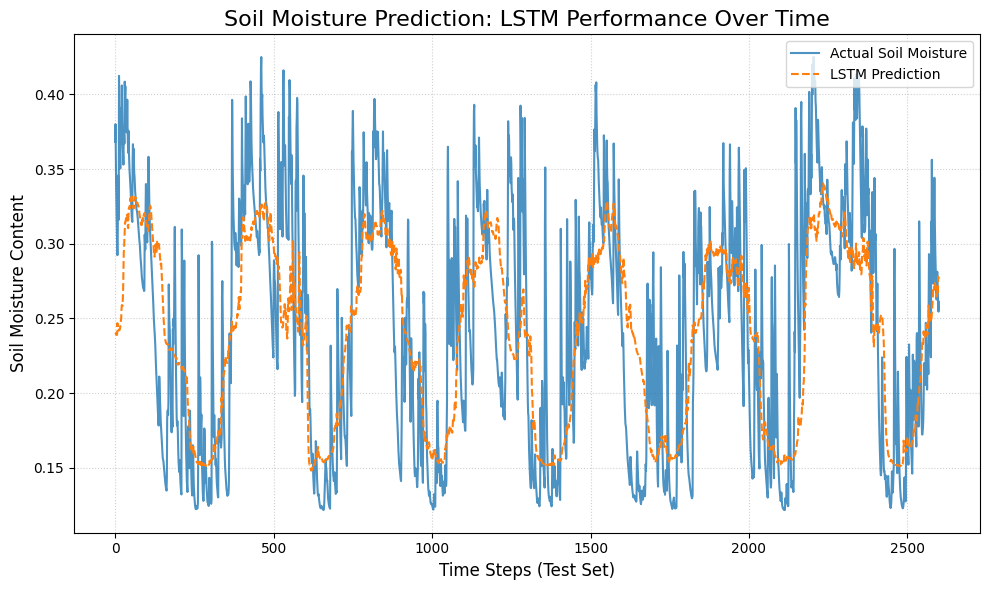

In [ ]:
import matplotlib.pyplot as plt

# Set the figure size for better visibility
plt.figure(figsize=(10, 6))

# Plotting the true values
plt.plot(y_test_inv, label='Actual Soil Moisture', color='#1f77b4', linewidth=1.5, alpha=0.8)

# Plotting the predicted values
plt.plot(preds_inv, label='LSTM Prediction', color='#ff7f0e', linewidth=1.5, linestyle='--')

# Adding visual cues for the "Smoothing" effect
plt.title('Soil Moisture Prediction: LSTM Performance Over Time', fontsize=16)
plt.xlabel('Time Steps (Test Set)', fontsize=12)
plt.ylabel('Soil Moisture Content', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

Transformer

In [ ]:
import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        # Create a matrix of [max_len, d_model] representing positional patterns
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        # x shape: [batch_size, seq_len, d_model]
        return x + self.pe[:, :x.size(1), :]

class SoilMoistureTransformer(nn.Module):
    def __init__(self, input_size, d_model=64, nhead=4, num_layers=2, dropout=0.2):
        super().__init__()
        
        # 1. Input Embedding: Projects raw features to d_model dimensions
        self.embedding = nn.Linear(input_size, d_model)
        
        # 2. Positional Encoding: Gives the model a sense of "time"
        self.pos_encoder = PositionalEncoding(d_model)
        
        # 3. Transformer Encoder: Standard PyTorch Encoder block
        encoder_layers = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=d_model * 4, 
            dropout=dropout,
            batch_first=True  # Keeps (batch, seq, feature) format
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        
        # 4. Output Layer: Projects final sequence state to a single prediction
        self.fc = nn.Linear(d_model, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Input x: [batch_size, seq_len, input_size]
        x = self.embedding(x)               # [batch_size, 60, 64]
        x = self.pos_encoder(x)             # [batch_size, 60, 64]
        
        # Transformer processing
        out = self.transformer_encoder(x)   # [batch_size, 60, 64]
        
        # Use the representation of the last time step (similar to LSTM logic)
        out = out[:, -1, :]                 # [batch_size, 64]
        
        return self.fc(self.dropout(out))   # [batch_size, 1]

In [ ]:
# Configuration
input_size = len(column_names) # Assuming this is available in your scope
d_model = 64                   # Internal dimension size
nhead = 4                      # Number of attention heads (d_model must be divisible by nhead)
num_layers = 2                 # Number of transformer blocks

model = SoilMoistureTransformer(input_size=input_size, d_model=d_model, nhead=nhead)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4) # Transformers often like lower LRs

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# --- 1. Model Definition ---

class SoilMoistureCNN(nn.Module):
    def __init__(self, input_size, num_filters=64, kernel_size=3):
        super().__init__()
        
        # Conv1d expects (batch, channels, length)
        # We use two layers to extract increasingly complex temporal patterns
        self.conv_block = nn.Sequential(
            nn.Conv1d(in_channels=input_size, out_channels=num_filters, kernel_size=kernel_size, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2), # Reduces 60 days to 30
            
            nn.Conv1d(in_channels=num_filters, out_channels=num_filters * 2, kernel_size=kernel_size, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)      # Global Average Pooling to flatten the temporal dimension
        )
        
        self.fc = nn.Sequential(
            nn.Linear(num_filters * 2, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # x shape: [batch, 60, input_size]
        # CNN needs: [batch, input_size, 60]
        x = x.permute(0, 2, 1)
        
        out = self.conv_block(x)      # Shape: [batch, 128, 1]
        out = out.view(out.size(0), -1) # Flatten to [batch, 128]
        return self.fc(out)

# --- 2. Data Preparation ---

def create_sequences(X, y, look_back=60, forecast_horizon=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - look_back - forecast_horizon + 1):
        X_seq.append(X[i : i + look_back])
        y_seq.append(y[i + look_back + forecast_horizon - 1])
    return np.array(X_seq), np.array(y_seq)

# Configuration
look_back = 60
forecast_horizon = 30

# Assuming X_scaled and y_scaled are defined
X_seq, y_seq = create_sequences(X_scaled, y_scaled, look_back, forecast_horizon)

split = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=False)

# --- 3. Training Loop ---

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_size = X_seq.shape[2]

model = SoilMoistureCNN(input_size=input_size).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 50
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {epoch_loss / len(train_loader):.4f}")

# --- 4. Evaluation ---

model.eval()
with torch.no_grad():
    preds = model(X_test_t.to(device)).cpu().numpy()

# Inverse Scale
preds_inv = scaler_y.inverse_transform(preds)
y_test_inv = scaler_y.inverse_transform(y_test)

rmse = np.sqrt(mean_squared_error(y_test_inv, preds_inv))
r2 = r2_score(y_test_inv, preds_inv)
mae = mean_absolute_error(y_test_inv, preds_inv)

print("-" * 20)
print("CNN Evaluation Metrics:")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")
print(f"MAE:  {mae:.4f}")

Epoch 0, Loss: 0.6944
Epoch 10, Loss: 0.5755
Epoch 20, Loss: 0.5600
Epoch 30, Loss: 0.5322
Epoch 40, Loss: 0.5043
--------------------
CNN Evaluation Metrics:
RMSE: 0.0572
R2:   0.4999
MAE:  0.0445


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import math
from sklearn.metrics import r2_score
import gc
import pandas as pd
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

# --- SHARED UTILITY ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def get_dataloader(X, y, batch_size=32, shuffle=False):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.float32)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)

# --- LSTM MODEL ---
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=32):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=2, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

# --- CNN MODEL ---
class CNNModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(input_size, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Linear(64, 1)
    def forward(self, x):
        x = x.permute(0, 2, 1)
        out = self.conv(x)
        return self.fc(out.view(out.size(0), -1))

# --- TRANSFORMER MODEL ---
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x): return x + self.pe[:, :x.size(1), :]

class TransformerModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.emb = nn.Linear(input_size, 64)
        self.pos = PositionalEncoding(64)
        layer = nn.TransformerEncoderLayer(d_model=64, nhead=4, batch_first=True)
        self.trans = nn.TransformerEncoder(layer, num_layers=2)
        self.fc = nn.Linear(64, 1)
    def forward(self, x):
        x = self.pos(self.emb(x))
        out = self.trans(x)
        return self.fc(out[:, -1, :])
    
def train_evaluate_generic(model, train_loader, X_test, y_test, lr=1e-3, epochs=20):
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # Training
    model.train()
    for epoch in range(epochs):
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            
    # Evaluation
    model.eval()
    with torch.no_grad():
        preds = model(torch.tensor(X_test, dtype=torch.float32).to(device)).cpu().numpy()
    return r2_score(y_test, preds)

def train_evaluate_lstm_reg(X_train, y_train, X_test, y_test):
    loader = get_dataloader(X_train, y_train, shuffle=False)
    model = LSTMModel(input_size=X_train.shape[2])
    return train_evaluate_generic(model, loader, X_test, y_test, lr=1e-3)

def train_evaluate_cnn_reg(X_train, y_train, X_test, y_test):
    loader = get_dataloader(X_train, y_train, shuffle=False)
    model = CNNModel(input_size=X_train.shape[2])
    return train_evaluate_generic(model, loader, X_test, y_test, lr=1e-3)

# Optimization: Tell PyTorch to use all available CPU cores
torch.set_num_threads(torch.get_num_threads())

def train_evaluate_transformer_reg(X_train, y_train, X_test, y_test):
    # 1. Smaller Model for CPU
    class LightTransformer(nn.Module):
        def __init__(self, input_size):
            super().__init__()
            self.emb = nn.Linear(input_size, 16) # Smaller embedding
            self.pos = PositionalEncoding(16)
            # Only 1 layer, 2 heads - much faster on CPU
            layer = nn.TransformerEncoderLayer(
                d_model=16, nhead=2, dim_feedforward=32, batch_first=True
            )
            self.trans = nn.TransformerEncoder(layer, num_layers=1)
            self.fc = nn.Linear(16, 1)

        def forward(self, x):
            x = self.pos(self.emb(x))
            out = self.trans(x)
            return self.fc(out[:, -1, :])

    # 2. Setup
    loader = get_dataloader(X_train, y_train, batch_size=64) # Larger batch for CPU efficiency
    model = LightTransformer(input_size=X_train.shape[2])
    optimizer = optim.Adam(model.parameters(), lr=1e-3) # Higher LR to converge faster
    criterion = nn.MSELoss()

    # 3. Fast Training Loop
    model.train()
    for epoch in range(10): # Reduced epochs
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

    # 4. Evaluation
    model.eval()
    with torch.no_grad():
        preds = model(torch.tensor(X_test, dtype=torch.float32)).numpy()
    
    return r2_score(y_test, preds)

def plot_regression_hero(results_df):
    plt.figure(figsize=(12, 7))

    models = [
        ('LSTM $R^2$', 'LSTM Performance', 'o'),
        ('CNN $R^2$', 'CNN Performance', 's'),
        ('Transformer $R^2$', 'Transformer Performance', '^'),
        ('Random Forest $R^2$', 'Random Forest Performance', 'd'),
        ('Persistence $R^2$', 'Persistence Baseline', 'x')
    ]

    for column, label, marker in models:
        plt.plot(
            results_df['Lead Time (Days)'],
            results_df[column],
            marker=marker,
            linewidth=2,
            label=label
        )

    plt.xlabel('Lead Time (Days)', fontsize=12)
    plt.ylabel('$R^2$ Score', fontsize=12)
    plt.xticks(results_df['Lead Time (Days)'])
    plt.ylim(None, 1.0) # R2 maxes at 1.0, but can go very negative
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()


results_list = []
lead_times = range(1, 31)

for lt in lead_times:
    # 1. Create Data for this lead time
    X_s, y_s = create_sequences(X_scaled, y_scaled, look_back=60, forecast_horizon=lt)
    split = int(0.8 * len(X_s))
    X_train, X_test = X_s[:split], X_s[split:]
    y_train, y_test = y_s[:split], y_s[split:]

    # 2. Run Evaluations
    r2_lstm = train_evaluate_lstm_reg(X_train, y_train, X_test, y_test)
    r2_cnn = train_evaluate_cnn_reg(X_train, y_train, X_test, y_test)
    r2_trans = train_evaluate_transformer_reg(X_train, y_train, X_test, y_test)

    # Random Forest (Flattened)
    rf = RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=42)
    X_train_rf = X_train.reshape(len(X_train), -1)
    X_test_rf = X_test.reshape(len(X_test), -1)

    rf.fit(X_train_rf, y_train.ravel())
    r2_rf = r2_score(y_test, rf.predict(X_test_rf))
    
    # Persistence (Predict today's value for T+lt)
    # Assumes target feature is the last column (-1)
    y_persist_pred = X_test[:, -1, -1] 
    r2_persist = r2_score(y_test, y_persist_pred)

    results_list.append({
        'Lead Time (Days)': lt,
        'LSTM $R^2$': r2_lstm,
        'CNN $R^2$': r2_cnn,
        'Transformer $R^2$': r2_trans,
        'Random Forest $R^2$': r2_rf,
        'Persistence $R^2$': r2_persist
    })
    
    print(f"Day {lt} processed. LSTM R2: {r2_lstm:.3f}")
    gc.collect()

results_df = pd.DataFrame(results_list)

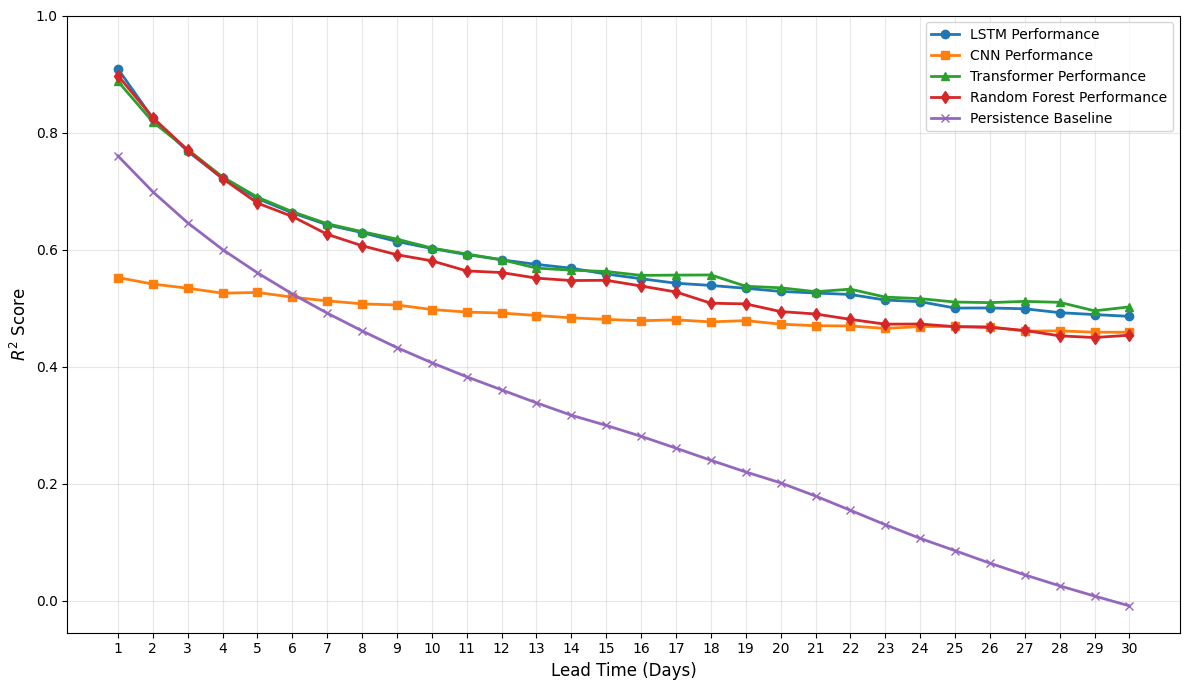

In [ ]:
import matplotlib.pyplot as plt

def plot_regression_hero(results_df):
    plt.figure(figsize=(12, 7))

    models = [
        ('LSTM $R^2$', 'LSTM Performance', 'o'),
        ('CNN $R^2$', 'CNN Performance', 's'),
        ('Transformer $R^2$', 'Transformer Performance', '^'),
        ('Random Forest $R^2$', 'Random Forest Performance', 'd'),
        ('Persistence $R^2$', 'Persistence Baseline', 'x')
    ]

    for column, label, marker in models:
        plt.plot(
            results_df['Lead Time (Days)'],
            results_df[column],
            marker=marker,
            linewidth=2,
            label=label
        )

    plt.xlabel('Lead Time (Days)', fontsize=12)
    plt.ylabel('$R^2$ Score', fontsize=12)
    plt.xticks(results_df['Lead Time (Days)'])
    plt.ylim(None, 1.0) # R2 maxes at 1.0, but can go very negative
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
plot_regression_hero(results_df) 